# Sensitivity Evaluation
This notebook showcases how IVON can be used to quantity model uncertainty through simple sensitivity metrics that are moderately cheap to compute

In [ ]:
# Install dependencies
!pip install -r requirements.txt

In [1]:
import torch
import matplotlib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

import numpy as np

import sys

# Pretty progress bars
from tqdm import tqdm

# Convenient handling of hyperparameter configs
from omegaconf import OmegaConf

# Import utility functions for loading trained checkpoints and datasets
from utils import load_checkpoint, load_dataset, denormalize

# Import functions for computing v_i and e_i
from sensitivity import get_variance_batch, get_error_batch

In [2]:
print("Python version:")
print(sys.version)

print("\nPyTorch version:")
print(torch.__version__)

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
print(f"\nUsing device: {device}")

Python version:
3.12.3 (main, Nov  6 2025, 13:44:16) [GCC 13.3.0]

PyTorch version:
2.9.1+cu128

Using device: cuda:0


In [3]:
# Global definitions

SHOWCASE_CLASS = 9  # CIFAR category to visualize
DATASET = "cifar10"

# Setup for plotting
matplotlib.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.latex.preamble": r"\usepackage{amsmath}",
    "figure.titlesize": 16,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12,
})


## Initialize DataLoader
We create a dataset and dataloader corresponding to only the class of interest

In [6]:

# We use the test set to assess the model on unseen data
train_set, _, test_set = load_dataset(name=DATASET)

# Train set only used for getting train set size N for variance estimates
train_set_size = train_set
del train_set

single_category_set = Subset(test_set, [i for i in range(len(test_set)) if test_set[i][1] == SHOWCASE_CLASS])
single_category_loader = DataLoader(single_category_set, shuffle=False, batch_size=10)


## Load Model Checkpoint
We load a checkpoint trained previously (see [Training.ipynb](./Training.ipynb) or [train.py](./train.py) for examples on how to train checkpoints)

In [14]:
model, optimizer, config = load_checkpoint(
    "ivon", 
    dataset_name=DATASET,
    model_name="resnet20",
    epoch=200, 
    device=device
)
model.eval()
print("Loaded IVON model trained with config:", OmegaConf.to_yaml(config), sep="\n\n", end="\n\n")

Loaded config: {'lr': 0.2, 'batch': 50, 'epochs': 200, 'warmup_epochs': 5, 'optim': {'lambda_': 45000, 'h0': 0.5, 'beta1': 0.9, 'beta2': 0.99999, 'weight_decay': 0.0002}, 'n_classes': 10}
IVON (
Parameter Group 0
    beta1: 0.9
    beta2: 0.99999
    clip_radius: inf
    ess: 45000
    hess: tensor([0.0926, 0.0866, 0.0899,  ..., 0.0952, 0.0901, 0.0905], device='cuda:0')
    hess_init: 0.5
    initial_lr: 0.2
    lr: 0.0
    mc_samples: 1
    momentum: tensor([6.0067e-04, 3.3848e-03, 3.2915e-03,  ..., 1.3181e-03, 3.7089e-05,
        2.8011e-03], device='cuda:0')
    numel: 272474
    weight_decay: 0.0002
)
Loaded IVON model trained with config:

lr: 0.2
batch: 50
epochs: 200
warmup_epochs: 5
optim:
  lambda_: 45000
  h0: 0.5
  beta1: 0.9
  beta2: 0.99999
  weight_decay: 0.0002
n_classes: 10




## Compute Sensitivities

In [8]:
all_sensitivities = []
for i, (x, y) in enumerate(tqdm(single_category_loader, desc="Evaluating sensitivities")):
    x = x.to(device)
    y = y.to(device)
    v = get_variance_batch(x=x, model=model, optimizer=optimizer, n_classes=config.n_classes, dataset_size=train_set_size)
    e = get_error_batch(x=x, y=y, model=model, n_classes=config.n_classes)

    sensitivity = v @ e[:, :, None]  # Shape (batch, nc, nc) @ (batch, nc, 1) -> (batch, nc, 1)
    sensitivity = sensitivity.squeeze(-1)  # Shape (batch, nc)
    sensitivity = sensitivity.norm(2, dim=-1)  # Shape (batch,)
    all_sensitivities += sensitivity.cpu().numpy().tolist()


Evaluating sensitivities: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:18<00:00,  5.40it/s]


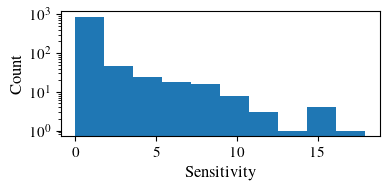

In [9]:
# Show a histogram over sensitivities for this category
fig = plt.figure(figsize=(4,2), layout="tight")
plt.hist(all_sensitivities)
plt.xlabel("Sensitivity")
plt.ylabel("Count")
plt.yscale("log")
plt.show()


## Show Example Images

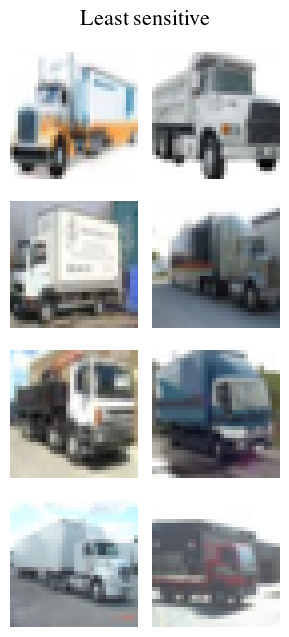

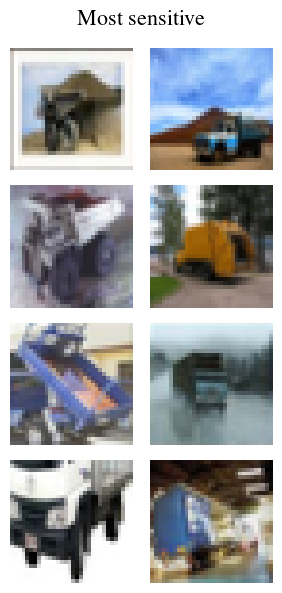

In [12]:
# Sort the images in terms of sensitivity
sorted_sensitivities = np.argsort(all_sensitivities)

# Show the least sensitive images
fig, axs = plt.subplots(4, 2, figsize=(3,6.5), layout="tight")
for i in range(axs.size):
    ax = axs.flatten()[i]
    img_idx = sorted_sensitivities[i]
    norm_img = single_category_set[img_idx][0]
    ax.imshow(
        denormalize(norm_img, dataset_name=DATASET).squeeze(0)
    )
    ax.axis("off")
plt.suptitle("Least sensitive")
plt.show()

# Show the most sensitive images
fig, axs = plt.subplots(4, 2, figsize=(3,6), layout="tight")
for i in range(axs.size):
    ax = axs.flatten()[i]
    img_idx = sorted_sensitivities[-i-1]
    norm_img = single_category_set[img_idx][0]
    ax.imshow(
        denormalize(norm_img, dataset_name=DATASET).squeeze(0)
    )
    ax.axis("off")
plt.suptitle("Most sensitive")
plt.show()
